# Домашнее задание: Кластеризация текстов

Сеть супермаркетов «Перекрёсток» собирает отзывы от клиентов по разным каналам: мобильное приложение, сайт, чековые анкеты. Отзывы включают как положительные оценки, так и жалобы — на персонал, доставку, свежесть товаров, наличие и т.д.

**Бизнес сталкивается с проблемой**:

* Отзывов слишком много, они разнообразны по формулировкам.
* Ручная обработка отзывов — долгая и неэффективная.
* Нельзя быстро понять, о чём говорят клиенты, какие темы повторяются.

**Цель бизнеса**:

* Автоматически группировать отзывы по смыслу, чтобы:
* обнаруживать повторяющиеся проблемы (например, "не тот товар", "просрочка"),
* оценивать работу конкретных магазинов и доставок,
* поддерживать продуктовые и операционные улучшения на основе обратной связи.



In [ ]:
!pip freeze > start_env.txt

# Читаем данные

Скачаем данные по отзывам на продукты. Предобработаем их и отфильтруем небольшое количество, чтобы потрогать руками различные алгоритмы, рассмотренные на лекции.

Для упрощения анализа кластеров и возможности здраво оценить, насколько результаты приемлемы, разделим данные на две явно разделенные по смыслу (во всяком случае, в среднем) группы: отзывы с максимальной оценкой и отзывы с минимальной оценкой.

In [1]:
# помогает с ошибкой чтения датасета с HF
!pip install fsspec==2023.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.6.0 which is incompatible.


In [1]:
!pip install -U datasets huggingface_hub fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pi

In [2]:
from datasets import load_dataset

# Загружаем train-часть датасета
dataset = load_dataset("lapki/perekrestok-reviews", split="train")
print(dataset)

README.md:   0%|          | 0.00/709 [00:00<?, ?B/s]

perekrestok.jsonl:   0%|          | 0.00/606M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/642682 [00:00<?, ? examples/s]

Dataset({
    features: ['product_id', 'product_name', 'product_category', 'product_price', 'review_id', 'review_author', 'review_text', 'rating'],
    num_rows: 642682
})


In [3]:
from datasets import load_dataset
import pandas as pd

N = 10000
df = dataset.to_pandas()
df = df[["review_id", "product_category", "product_name", "review_text", "rating"]]
df = df.sort_values(by="review_id").head(N)
df.head(2)


,review_id,product_category,product_name,review_text,rating
128218,1493,Для мам и детей,Сок Сады Придонья Яблоко зеленое 125мл,Самые лучшие соки. Всегда беру детям только их...,5.0
426797,1496,Сладости,Пастила Белевская Пастильная Мануфактура Класс...,"Вкуснее, чем у известных конкурентов.",5.0


In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Применяем очистку
df["clean_text"] = df["review_text"].apply(clean_text)
df.head(2)

,review_id,product_category,product_name,review_text,rating,clean_text
128218,1493,Для мам и детей,Сок Сады Придонья Яблоко зеленое 125мл,Самые лучшие соки. Всегда беру детям только их...,5.0,самые лучшие соки. всегда беру детям только их...
426797,1496,Сладости,Пастила Белевская Пастильная Мануфактура Класс...,"Вкуснее, чем у известных конкурентов.",5.0,"вкуснее, чем у известных конкурентов."


In [5]:
neg = df[df["rating"] == 1.0].sort_values(by="review_id")[:500]
pos = df[df["rating"] == 5.0].sort_values(by="review_id")[:500]
cut_df = pd.concat([neg, pos]).reset_index(drop=True)
cut_df["rating"].value_counts()

,count
rating,
1.0,500
5.0,500


In [7]:
cut_df.head(2)

,review_id,product_category,product_name,review_text,rating,clean_text
0,3972,"Чай, кофе, сахар",Сахар песок белый 1кг,запекала сахар вместе с дыней. дыня совсем не ...,1.0,запекала сахар вместе с дыней. дыня совсем не ...
1,4462,"Чай, кофе, сахар",Кофе молотый Julius Meinl Prasident 250г,Почти без запаха.,1.0,почти без запаха.


# Алгоритмы визуализации - 5 баллов

Реализуйте функции для сжатия эмбеддингов до двумерного пространства с помощью подходов t-SNE и UMAP. Каждая функция должна строить изображения поданных на вход эмбеддингов в пространстве, а также учитывать, какое расстояние между эмбеддингами мы считаем (евклидово или косинусное).

Протестируйте их на небольшом семпле.

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import umap


# Можно реализовать через одну функцию, но для тестирования разных сетапов было удобно делать две отдельно

# Визуализация через t-SNE
def plot_embeddings(embeds, title, metric="euclidean"):
    print("строим tsne")

    tsne = TSNE(
        n_components=2,
        metric=metric,
        init="random",
        learning_rate="auto",
        random_state=42,
        perplexity=min(30, max(2, len(embeds) - 1))
    )

    embeds_2d = tsne.fit_transform(embeds)

    plt.figure(figsize=(8, 6))
    plt.scatter(embeds_2d[:, 0], embeds_2d[:, 1], alpha=0.7)
    plt.title(title)
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")
    plt.grid(True)

    plt.show()


# Визуализация через UMAP
def plot_embeddings_umap(embeds, title, metric="euclidean"):
    print("строим umap")

    reducer = umap.UMAP(
        n_components=2,
        metric=metric,
        random_state=42,
        n_neighbors=min(15, len(embeds) - 1),
        min_dist=0.1
    )

    embeds_2d = reducer.fit_transform(embeds)

    plt.figure(figsize=(8, 6))
    plt.scatter(embeds_2d[:, 0], embeds_2d[:, 1], alpha=0.7)
    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.grid(True)

    plt.show()

строим tsne


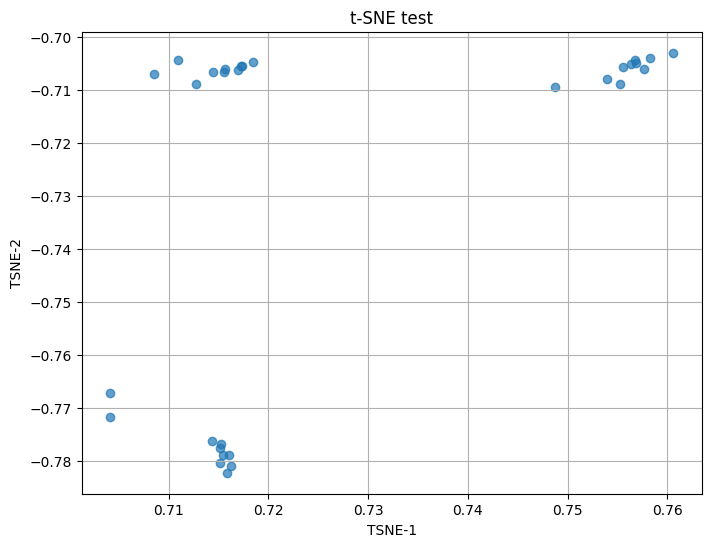

строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


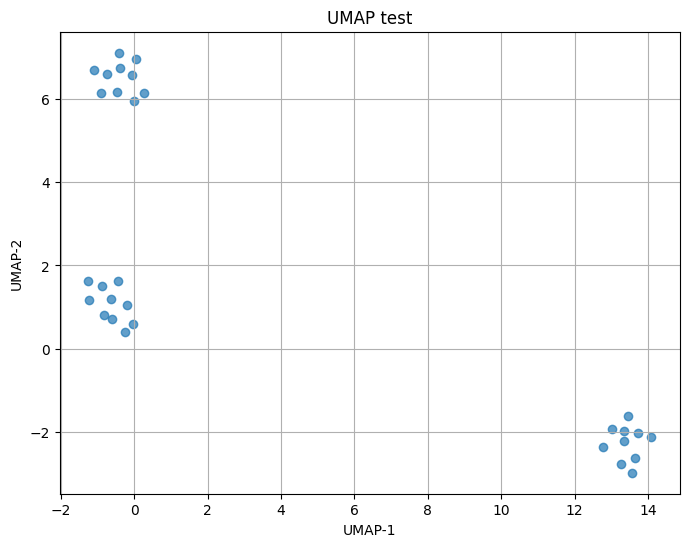

In [8]:
embs = np.concatenate([np.random.rand(10, 3), np.random.rand(10, 3) + 2, np.random.rand(10, 3) - 1], axis=0)
plot_embeddings(embs, "t-SNE test", metric="euclidean")
plot_embeddings_umap(embs, "UMAP test", metric="euclidean")

# Зависимость кластеров от эмбеддера - 5 баллов

В данной части предлагается оценить, насколько эмбеддер на качество кластеризации может влиять:
а) эмбеддер
б) выбранная метрика расстояния

Возьмите следующие две модели:
1) "ai-forever/FRIDA" -- хороший качественный эмбеддер
2) "cointegrated/rubert-tiny2" -- достаточно слабый по современным меркам эмбеддер

Реализуйте подгрузку этой модели через класс SentenceTransformer и постройте визуализацию кластеров
а) через функцию с UMAP и через функцию с t-SNE
б) и для каждого варианта -- визуализацию с евклидовым расстоянием и с косинусным расстоянием
в) и для каждого варианта -- с эмбеддером FRIDA и с эмбеддером rubert-tiny2

Итого должно получиться 8 графиков. Сделайте выводы, какой эмбеддер визуально разграничивает данные лучше.

In [7]:
from sentence_transformers import SentenceTransformer

texts = cut_df["clean_text"].values

# ---- Ваш код здесь ----
print("загружаем две модели и считаем эмбеддинги для каждой от texts, а затем рисуем графики функциями выше")
frida = SentenceTransformer("ai-forever/FRIDA")
rubert = SentenceTransformer('cointegrated/rubert-tiny2')



загружаем две модели и считаем эмбеддинги для каждой от texts, а затем рисуем графики функциями выше


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/509 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

строим tsne


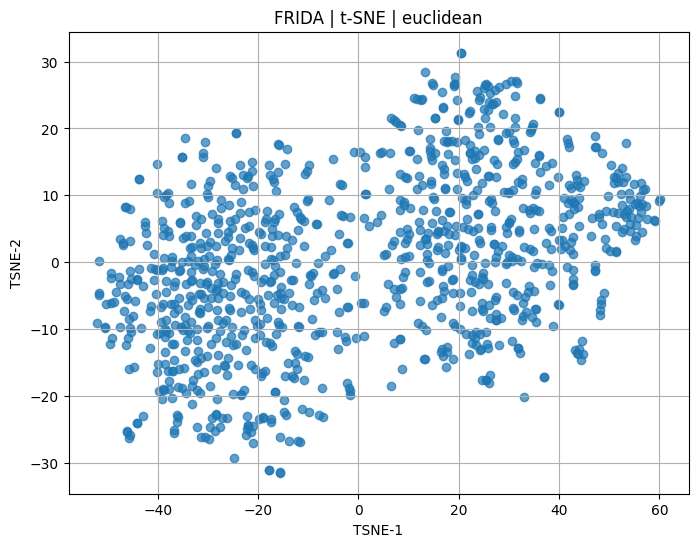

строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


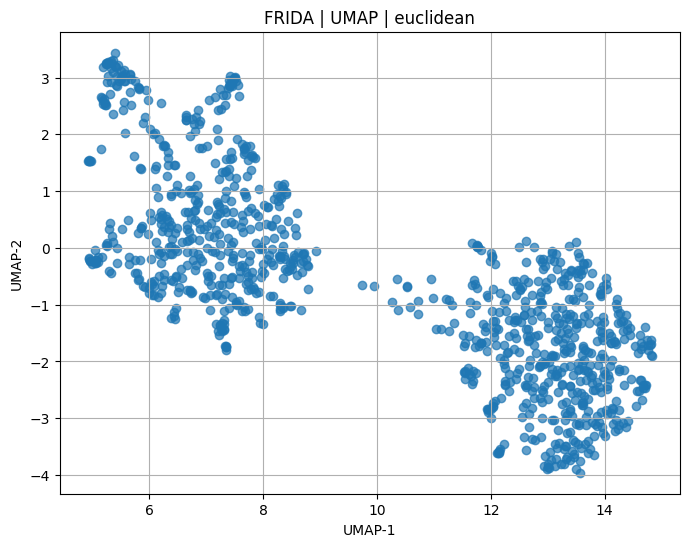

строим tsne


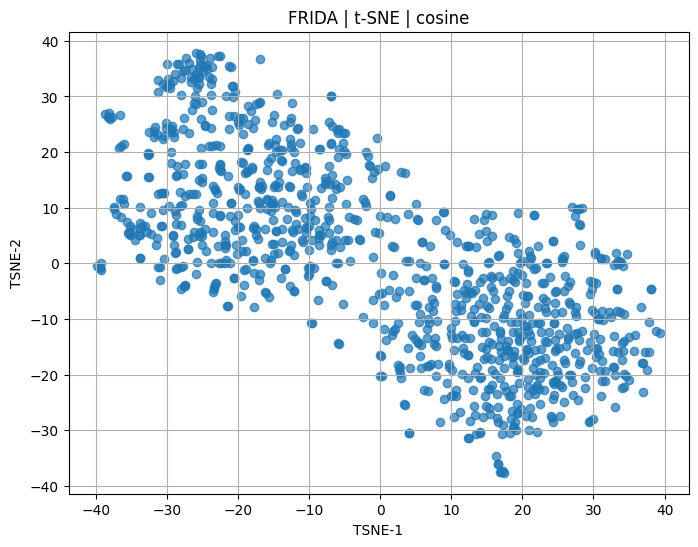

строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


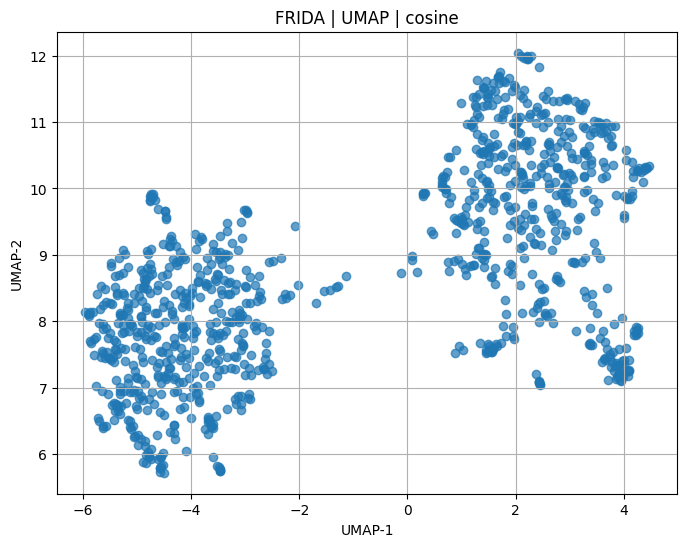

строим tsne


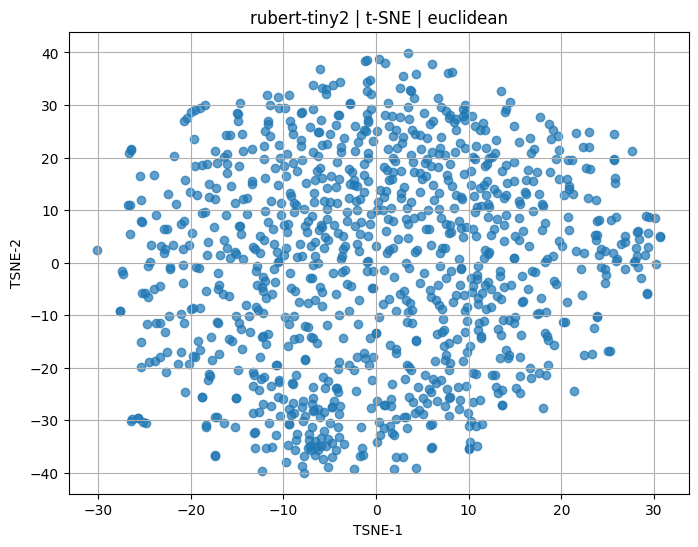

строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


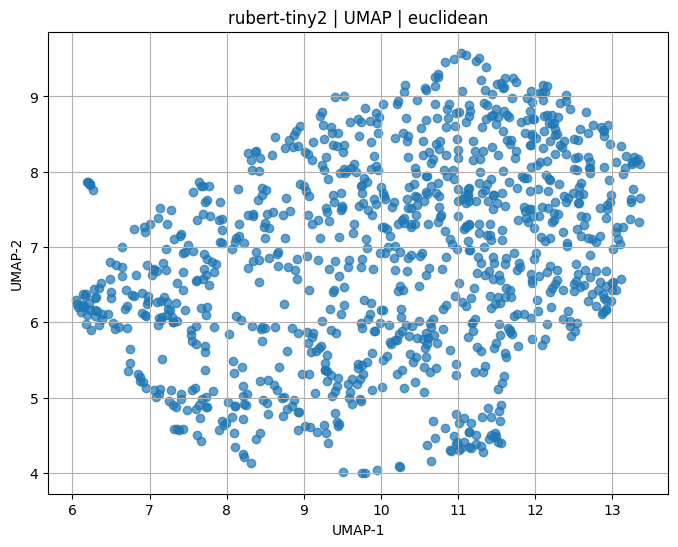

строим tsne


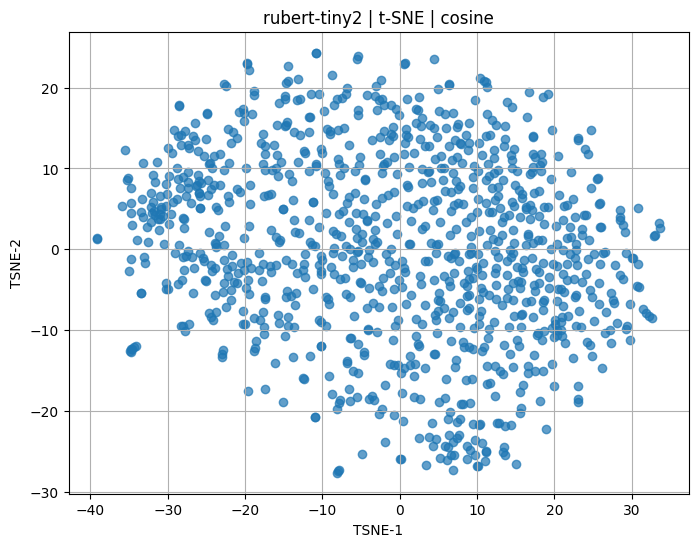

строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


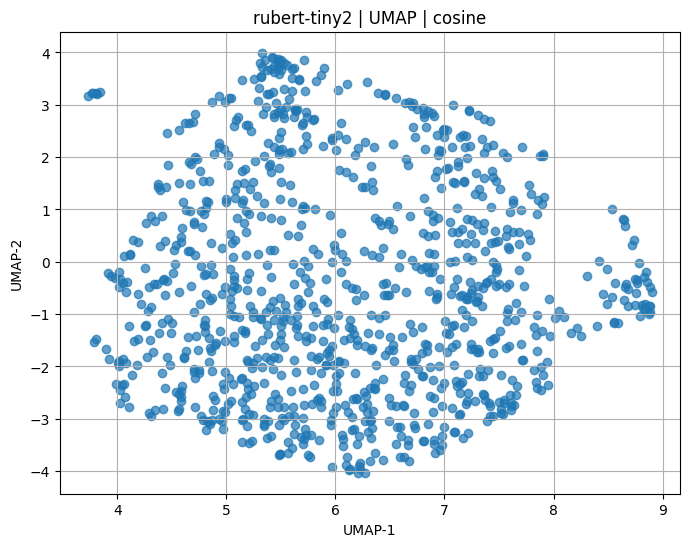

In [8]:
frida_embeds = frida.encode(texts.tolist() , show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
rubert_embeds = rubert.encode(texts.tolist() , show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)

configs = [
        ("FRIDA", frida_embeds),
        ("rubert-tiny2", rubert_embeds)]
metrics = ["euclidean", "cosine"]


for model_name, embeds in configs:
    for metric in metrics:
        plot_embeddings(
            embeds,
            title=f"{model_name} | t-SNE | {metric}",
            metric=metric
        )
        plot_embeddings_umap(
            embeds,
            title = f"{model_name} | UMAP | {metric}",
            metric=metric
        )

# # ---- Конец кода ----

### Эмбедер "ai-forever/FRIDA" лучше, особенно с UMAP

# Зависимость кластеров от алгоритма кластеризации - 10 баллов

Реализуйте кластеризацию выбранных нами текстов через алгоритмы KMeans, MiniBatchKMeans, HDBSCAN. Сравните эти алгоритмов визуально и по метрикам. В качестве метрик используйте silhouette_score для безотносительной оценки качества и adjusted_rand_score для оценки качества относительно рейтинга (1.0 или 5.0). Визуализацию делайте с помощью UMAP.

compare_clusterers принимает на вход кластеризуемые эмбеддинги и, опционально, референсные значения кластеров (в нашем случае -- принадлежность к рейтингу). Функция должна отрисовывать кластера в пространстве для трех алгоритмов и возвращать метрики по каждому из них в виде словаря.

In [9]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


def compare_clusterers(embeddings, true_labels=None, n_clusters=5):
    results = {}

    clusterers = {
        "KMeans": KMeans(
            n_clusters=n_clusters,
            random_state=42,
            n_init=10
        ),
        "MiniBatchKMeans": MiniBatchKMeans(
            n_clusters=n_clusters,
            random_state=42,
            batch_size=256,
            n_init=10
        ),
        "HDBSCAN": HDBSCAN()
    }
    # ---- Ваш код здесь ----
    print("кластеризуем и тремя моделями и считаем метрики силуэт и ari")

    for name, clusterer in clusterers.items():
        predicted_labels = clusterer.fit_predict(embeds)

        #unique_labels = np.unique(predicted_labels)

        sil = silhouette_score(embeds, predicted_labels)

        ari = adjusted_rand_score(true_labels, predicted_labels)

        results[name] = {
            "silhouette_score": sil,
            "adjusted_rand_score": ari
        }

        # Отрисовка
        plot_embeddings_umap(embeddings, name, metric="euclidean")

    return results


кластеризуем и тремя моделями и считаем метрики силуэт и ari
строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


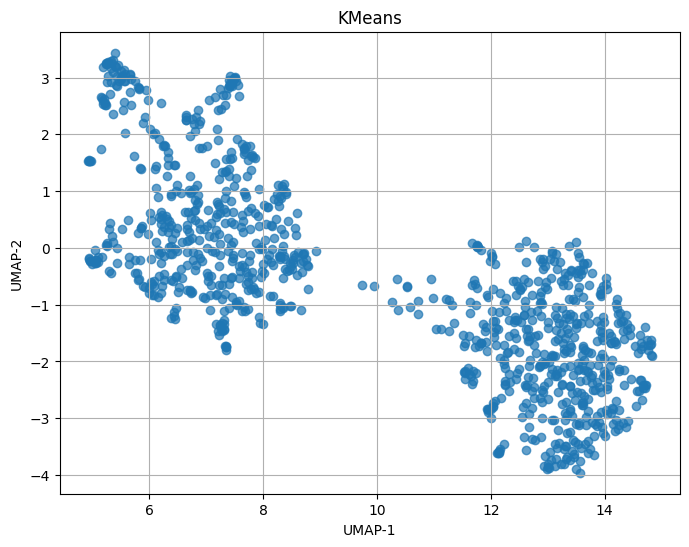

строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


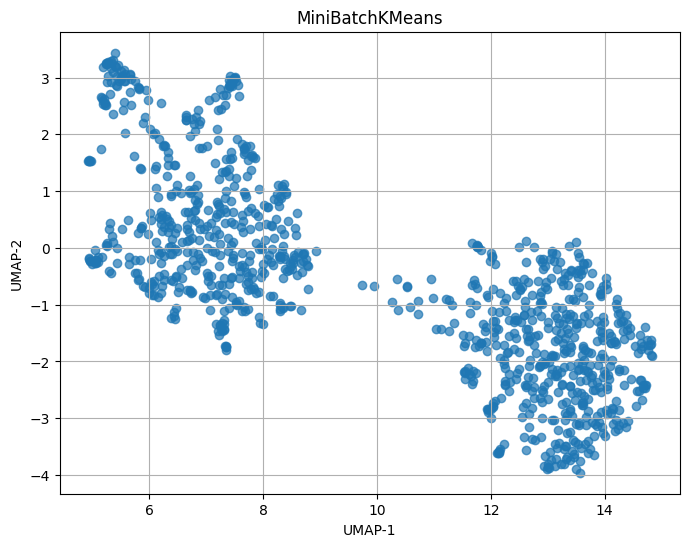

строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


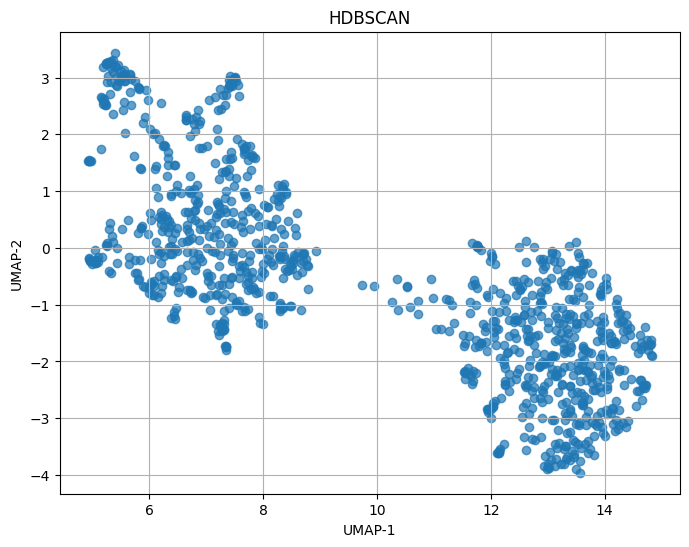

{'KMeans': {'silhouette_score': np.float32(0.043510005),
  'adjusted_rand_score': 0.10038633527230502},
 'MiniBatchKMeans': {'silhouette_score': np.float32(0.04229802),
  'adjusted_rand_score': 0.056538259746046815},
 'HDBSCAN': {'silhouette_score': np.float32(0.04079771),
  'adjusted_rand_score': 0.0015565557128388817}}

In [10]:
# embeddings: np.array, shape = (n_samples, embedding_dim)
# true_labels: list или np.array (опционально)

good_embeds  = frida_embeds
true_labels = (cut_df["rating"] == 5.0).apply(int)
results = compare_clusterers(good_embeds, true_labels=true_labels, n_clusters=5)
results

# Интерпретируемость кластеров

## BERTopic - 5 баллов

Попробуем построить интерпретацию получаемых кластеров с помощью BERTopic, реализованного в виде отдельного фреймворка (строит кластера, считает c-TF-IDF, отбирает самые частотные и характеризующие кластер слова).

Если считать частотные слова напрямую, то в топе окажется много служебные слов, которые называют "стоп-словами". Игнорируйте эти слова при построении BERTopic -- это можно сделать с помощью переопределения vectorizer_model, заменив его на sklearn.CountVectorizer с использованием nltk stopwords.

In [11]:
!pip install -q bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.2 MB/s eta 0:00:00


In [12]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

# import plotly.io as pio
# pio.renderers.default = "notebook_connected"

from plotly.io import renderers
renderers.default = "notebook_connected" # интерактив в Jupyter/Colab

In [13]:

# ---- Ваш код здесь ----
print("стоп-слова и векторайзер")

from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

russian_stopwords = stopwords.words("russian")
vectorizer = CountVectorizer(stop_words=russian_stopwords)


embedding_model = frida #
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer,
    language="russian",
    calculate_probabilities=True,
    verbose=False
)

# ---- Конец кода ----

стоп-слова и векторайзер


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [14]:
# ---- Ваш код здесь ----
print("вычисляем топики в каждом кластере, визуализируем / выводим для каждого кластера топовые слова")
# ---- Конец кода ----
topics, probs = topic_model.fit_transform(texts)


вычисляем топики в каждом кластере, визуализируем / выводим для каждого кластера топовые слова


In [15]:
for i in range(5):
    print(f"Text: {texts[i][:100]}")
    print(f"Topic: {topics[i]}")
    print()

Text: запекала сахар вместе с дыней. дыня совсем не пропеклась по причине плохой свертываемости сахара. вы
Topic: 1

Text: почти без запаха.
Topic: 1

Text: не понравились. начинки мало. к тому же в процессе варки все вареники "раскрылись" как цветочки , на
Topic: 1

Text: невозможно есть! очень невкусно
Topic: 1

Text: недоквашенная она какая-то, много воды
Topic: 1



In [16]:
# делаем кластеризацию
kmean =  KMeans(n_clusters=2,random_state=42)
predicted_labels = kmean.fit_predict(frida_embeds)

df_topics = pd.DataFrame({
    "text": texts,
    "cluster": predicted_labels,
    "topic": topics
})

In [17]:
df_topics.head()

,text,cluster,topic
0,запекала сахар вместе с дыней. дыня совсем не ...,0,1
1,почти без запаха.,1,1
2,не понравились. начинки мало. к тому же в проц...,0,1
3,невозможно есть! очень невкусно,0,1
4,"недоквашенная она какая-то, много воды",0,1


In [18]:
cluster_topic_counts = (
    df_topics.groupby(["cluster", "topic"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
)

for cluster_id in sorted(cluster_topic_counts["cluster"].unique()):
    print("=" * 60)
    print(f"КЛАСТЕР {cluster_id}")

    cluster_topics = cluster_topic_counts[cluster_topic_counts["cluster"] == cluster_id]
    cluster_topics = cluster_topics.head(2)

    if cluster_topics.empty:
        print("Темы не найдены")
        continue

    for _, row in cluster_topics.iterrows():
        topic_id = row["topic"]
        count = row["count"]

        print(f"\nТема {topic_id} | документов: {count}")

        words = topic_model.get_topic(topic_id)
        top_words = [word for word, _ in words[:10]]
        print("Топ-слова:", ", ".join(top_words))

КЛАСТЕР 0

Тема 1 | документов: 484
Топ-слова: это, очень, вкус, запах, невозможно, пришлось, буду, просто, внутри, рекомендую

Тема 0 | документов: 5
Топ-слова: очень, вкусный, вкус, спасибо, хороший, это, рекомендую, средство, вкусные, просто
КЛАСТЕР 1

Тема 0 | документов: 502
Топ-слова: очень, вкусный, вкус, спасибо, хороший, это, рекомендую, средство, вкусные, просто

Тема 1 | документов: 9
Топ-слова: это, очень, вкус, запах, невозможно, пришлось, буду, просто, внутри, рекомендую


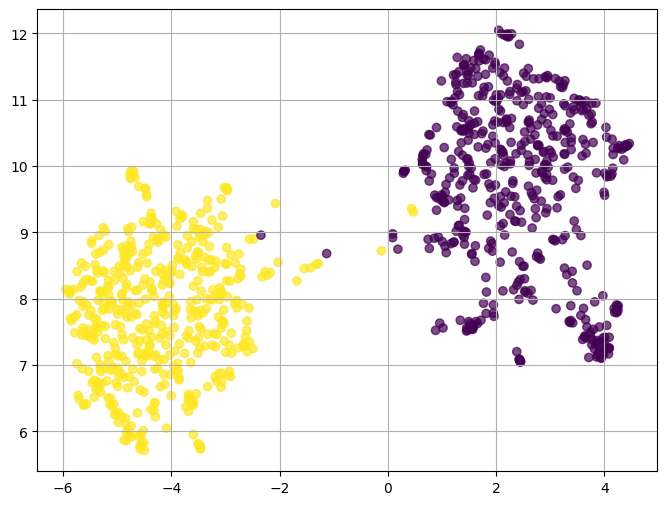

In [19]:
reducer = umap.UMAP(
    n_components=2,
    metric=metric,
    random_state=42,
    n_neighbors=min(15, len(embeds) - 1),
    min_dist=0.1
)

embeds_2d = reducer.fit_transform(frida_embeds)

plt.figure(figsize=(8, 6))
plt.scatter(embeds_2d[:, 0], embeds_2d[:, 1], alpha=0.7, c = topics)
plt.grid(True)

plt.show()

## Интерпретация через LLM - 15 баллов

Реализуйте интерпретацию кластеров с помощью LLM: кластеризуйте данные с помощью HDBSCAN, удалите аномалии (кластер -1), затем для каждого кластера насемплируйте 5-10 примеров.

Возьмите любую адекватную для русского языка LLM (например, saiga-yandexgpt из первой дз, либо для скорости можно взять qwen-2-0.5b -- хотя по качеству она будет достаточно слабой), и напишите к ней промпт, по которому данная ллм на основе семплированных отзывов должна написать короткое описание кластера.

В качестве результата выведите датафрейм, в котором для каждого кластера будет номер кластера, короткое описание кластера и использованный семпл.

In [20]:
# чистим cuda память
import gc
import torch

torch.cuda.empty_cache()
torch.cuda.empty_cache()
gc.collect()

36023

In [23]:
import pandas as pd
import numpy as np
import random
from sentence_transformers import SentenceTransformer
from sklearn.cluster import HDBSCAN
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

from sklearn.metrics.pairwise import cosine_distances
pd.set_option("display.max_colwidth", None)


# ---- Ваш код здесь ----
print("реализуем семлпирование и разметку")

def cluster_with_hdbscan(embeddings, min_cluster_size=15, min_samples=None):
    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples
    )
    labels = clusterer.fit_predict(embeddings)
    return labels

def sample_texts_per_cluster(texts, cluster_labels, n_samples=7, random_state=42):
    df = pd.DataFrame({
        "text": list(texts),
        "cluster": cluster_labels
    })

    df = df[df["cluster"] != -1].copy()

    samples = []

    for cluster_id in sorted(df["cluster"].unique()):
        cluster_df = df[df["cluster"] == cluster_id]

        sample_n = min(n_samples, len(cluster_df))
        sampled = cluster_df.sample(sample_n, random_state=random_state)

        samples.append({
            "cluster": cluster_id,
            "sample_texts": sampled["text"].tolist()
        })

    return pd.DataFrame(samples)

def load_llm(model_name="Qwen/Qwen2-0.5B-Instruct"):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype="auto",
        device_map="auto"
    )

    generator = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer
    )
    return generator


def build_cluster_prompt(sample_texts):
    reviews_block = "\n".join(
        [f"{i+1}. {text}" for i, text in enumerate(sample_texts)]
    )

    prompt = f"""
        Ты анализируешь несколько отзывов с общей темой.

        Отзывы:
        {reviews_block}

        Твоя задача:
        - определить, что объединяет эти отзывы;
        - кратко описать общую тему;
        - Важно: длина ответа максимум 15 слов.

        Ответ:
            """.strip()

    return prompt

def describe_cluster(generator, sample_texts, max_new_tokens=120):
    prompt = build_cluster_prompt(sample_texts)

    output = generator(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        return_full_text=False
    )

    description = output[0]["generated_text"].strip()
    return description

def interpret_clusters_with_llm(
    texts,
    embeddings,
    model_name="Qwen/Qwen2-0.5B-Instruct",
    min_cluster_size=15,
    min_samples=None,
    n_samples_per_cluster=7,
    random_state=42
):
    # 1. Кластеризация
    cluster_labels = cluster_with_hdbscan(
        embeddings,
        min_cluster_size=min_cluster_size,
        min_samples=min_samples
    )

    # 2. Семплы по кластерам
    sampled_df = sample_texts_per_cluster(
        texts=texts,
        cluster_labels=cluster_labels,
        n_samples=n_samples_per_cluster,
        random_state=random_state
    )

    # 3. Загрузка LLM
    generator = load_llm(model_name)

    # 4. Описания кластеров
    descriptions = []
    for _, row in sampled_df.iterrows():
        cluster_id = row["cluster"]
        sample_texts = row["sample_texts"]

        description = describe_cluster(generator, sample_texts)

        descriptions.append({
            "cluster": cluster_id,
            "cluster_description": description,
            "sample_texts": sample_texts
        })

    result_df = pd.DataFrame(descriptions)
    return result_df, cluster_labels


result_df, cluster_labels = interpret_clusters_with_llm(
    texts=texts,
    embeddings=frida_embeds,
    model_name="Qwen/Qwen2-1.5B-Instruct",
    min_cluster_size=15,
    n_samples_per_cluster=15
)

result_df


# ---- Конец кода ----

реализуем семлпирование и разметку


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


,cluster,cluster_description,sample_texts
0,0,Все отзывы связаны с质量问题 или недовольством продуктом. \n\n Общая тема: Продукт или услуга не соответствует ожиданиям потребителя. \n\n Длина ответа: 15 слов.,"[очень вкусный мёд!, что то неприятно соленое. стыдно за поставщика., не понравился, совсем не то, на что рассчитывала! какой0то сладкий, десертный вкус с странным химическим запахом, совсем не то, что в ресторанах(, ужасный краб.,ужасная мелкая ,пересоленная смесь с химическим привкусом.годится только для помойного ведра.а купила для салата.выбросила.ни кому не рекомендую., капуста ужасная, половина плохой, много льда. почти всю пачку выкинула, никогда больше не куплю., пирожное не понравилось. тесто корзиночки толстое, сухое, твердое - можно зубы сломать. не рекомендую !!!, брала раньше и очень понравилась. заказала к старому новому году (заказ на 12.01.2019). получила жесть (сверх солёные хвостовые куски). ужас!!!! я в шоке!!! не рекомендую!!!! жаль, что нет оценки минус., отвратительная колбаса! может быть попалась партия один жир не жуётся вообще. была любимая в нашей семье именно за отсутствие прожилок. ужасная изжога после. очень жаль потраченных денег. в помойку, при готовке сильный запах (хряка). аппетита не вызывает. больше покупать не планируем, это не вкусно, а даже отвратительно! уже при жарке почувствовала неприятный запах полуфабрикатов. фу, это просто на вкус хуже бумаги, сухая, кислая, содержит муку не заявленную в составе, меренгу я вообще не увидела. не советую!!!, внутри упаковки жидкость, рыба очень солёная и не копченая, ведь она находилась в солёном растворе. отвратительный вкус, на выброс... очень обидно за выброшенные деньги. больше никогда не буду покупать рыбу холодного копчения ооо ""сити-фуд"", мо,чеховского р-на, с.шарапово, не понравились! как и фрикадельки этой фирмы. сплошные жилки и комочки, постоянно выплевывая, есть не очень то приятно ((, отвратительная кукуруза. согласна с предыдущим отзывов. есть невозможно. на выброс. ребёнок от этой кукурузы начал чесаться(((, сметанка очень приличного качества, натуральная, без подделок, вмеру густая, сладенькая. полностью в моём вкусе!]"
1,1,"Все отзывы говорят о том, что средство эффективно и приятно пахнет. Это чистящее средство для сантехники. \n\n Объединение отзывов: Все отзывы говорят о том, что средство эффективно и приятно пахнет. Это чистящее средство для сантехники. \n\n Тема: Чистящее средство для сантехники. \n\n Длина ответа: 15 слов.","[лучшее чистящее средство для сантехники. отчищает любую грязь и приятно пахнет. пользуемся этим средством с момента появления его в продаже. рекомендую всем, кто хочет чистоты!, обожаю это средство. чистит любые поверхности без царапин, легко смывается водой. накипь, жир, налет - все пл силам! а ещё балдею от его запаха., отличное средство! использую много лет, уже не знаю, как без него обходиться) всегда беру атлантику - приятный запах в ванной после уборки., очень довольна водой. всегда заказываю ее. хорошее соотношение цена-качество., действительно приятный - цветочный с легкими химическими нотками, не резкий и ненавязчивый. после уборки, ещё некоторое время остаётся в воздухе, но это нисколько не раздражает. средство хорошое, с налетом и загрязнениями справляется полностью,, удобный блок, хватает надолго. хорошо отчищает, придает запах свежести - не резкий. хорошо пенится. соотношение цена/качество тоже устраивает., идеальное средство как для чистки унитазов, так и для мытья пола. пользуюсь уже не первый год, лучшего еще ни чего не нашла. очень хорошо отбеливает унитаз и удаляет запахи. добавляю колпачок в ведро с водой для пола, дезинфицирует не оставляя следов и липкости на полу., томатный сок этой фирмы покупаем уже не первый раз, очень отличается от соков, сделанных из томатной пасты, это отжатый сок, очень вкусный., самая натуральная томатная паста! пкупала очень многие, но только эта пришлась по вкусу. в составе только натуральные продукты. это очень радует. использую всегда только ее в готовке

In [ ]:
## Модель небольшая потому качество суммаризации не очень

# snorkel / flyingsquid - 10 баллов

В данном разделе предлагается воспользоваться фреймворком для semi-supervised кластеризации, в котором можно определить lf-функции, отображающие некоторые эвристики, и использовать их для автоматической доразметки данных. Необходимо написать как минимум 9 новых правдоподобных правил (то есть суммарно должно быть 10).

В качестве альтернативы допускается использовать flyingsquid (чуть устаревший вариант) -- шаблон кода под него расположен ниже

Для лучшего понимания интерфейса и функциональности предлагается ознакомиться с документацией фреймворков в сети.

In [24]:
!pip install snorkel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 2.3 MB/s eta 0:00:00


In [25]:
import numpy as np
import pandas as pd
from snorkel.labeling import labeling_function, PandasLFApplier
from snorkel.labeling.model import LabelModel


df = pd.DataFrame({"text": texts})

texts = cut_df["clean_text"].values
# frida_embeds = frida_model.encode(texts, convert_to_numpy=True)
print(len(texts), len(frida_embeds))

df = pd.DataFrame({"text": texts})


ABSTAIN = -1
DELIVERY = 0
QUALITY = 1
SERVICE = 2
PRICE = 3


@labeling_function()
def lf_has_delivery_keywords(series):
    return DELIVERY if any(w in series.text.lower() for w in ["доставка", "курьер", "привезли", "опоздал", "вовремя"]) else ABSTAIN

@labeling_function()
def lf_delivery_delay(series):
    return DELIVERY if any(w in series.text.lower() for w in ["опоздал", "задержка", "долго везли"]) else ABSTAIN


@labeling_function()
def lf_delivery_speed(series):
    return DELIVERY if any(w in series.text.lower() for w in ["быстро доставили", "вовремя", "оперативно"]) else ABSTAIN


@labeling_function()
def lf_quality_good(series):
    return QUALITY if any(w in series.text.lower() for w in ["свежий", "вкусный", "качественный", "отличный"]) else ABSTAIN


@labeling_function()
def lf_quality_bad(series):
    return QUALITY if any(w in series.text.lower() for w in ["испорченный", "невкусный", "просроченный", "плохое качество"]) else ABSTAIN


@labeling_function()
def lf_service_bad(series):
    return SERVICE if any(w in series.text.lower() for w in ["хам", "грубый", "не ответили", "игнорируют"]) else ABSTAIN


@labeling_function()
def lf_service_good(series):
    return SERVICE if any(w in series.text.lower() for w in ["вежливый", "поддержка", "помогли", "быстро ответили"]) else ABSTAIN


@labeling_function()
def lf_price_expensive(series):
    return PRICE if any(w in series.text.lower() for w in ["дорого", "высокая цена", "слишком дорого"]) else ABSTAIN


@labeling_function()
def lf_price_cheap(series):
    return PRICE if any(w in series.text.lower() for w in ["дешево", "недорого", "выгодно", "хорошая цена"]) else ABSTAIN


@labeling_function()
def lf_quality_packaging(series):
    return QUALITY if any(w in series.text.lower() for w in ["упаковка", "помята", "порвана"]) else ABSTAIN


lfs = [
    lf_has_delivery_keywords,
    lf_delivery_delay,
    lf_delivery_speed,
    lf_quality_good,
    lf_quality_bad,
    lf_quality_packaging,
    lf_service_bad,
    lf_service_good,
    lf_price_expensive,
    lf_price_cheap
]

applier = PandasLFApplier(lfs=lfs)
L = applier.apply(df)

label_model = LabelModel(cardinality=4, verbose=True)
label_model.fit(L, n_epochs=200, log_freq=50)

preds = label_model.predict(L)

df["snorkel_label"] = preds

df["snorkel_label"].value_counts()


1000 1000


100%|██████████| 200/200 [00:01<00:00, 103.85epoch/s]


,count
snorkel_label,
-1,882
1,94
0,15
3,9


In [26]:
# ABSTAIN = -1
# DELIVERY = 0
# QUALITY = 1
# SERVICE = 2
# PRICE = 3

df.query("snorkel_label == 0").head() ##

,text,snorkel_label
22,"это не мясо, это жилы привезли мясо там рядом лежало когда упаковывали",0
75,"лук не понравился. привезли уже проросший, а на вкус совсем не салатный. как обычный репчатый.",0
163,"нам повезло меньше, из 3 гранатов 2 были незрелые - внутри белые и кислые. остальные продукты привезли хорошие.",0
206,возврат курьеру до оплаты зелёёёные деревянные,0
232,"на картинке одно манго,а привезли совсем другое... по виду привезли обычный который у них по цене 93р за штуку. обидно очень. положила зреть в темное место ибо зелёный и твёрдый.",0


In [27]:
df.query("snorkel_label == 3 ") ##

,text,snorkel_label
42,напиток из дешевой томатной пасты с неприятным вкусом. эх... где же томатный сок времен ссср.,3
410,никаких ребрышек там нет! одни обрезки! да еще покупала дорого. обман полнейший. никогда больше не кулю.,3
500,самые лучшие соки. всегда беру детям только их. и недорого.,3
548,"качеству пармалат доверяю на все 100! дороговато, конечно, но зато натуральное!",3
609,"заказали эти сливки и карамельные. эти вкусные, а карамельные просто бомба! кофе с ними становится как коктейль из дорогой кофейни!",3
644,"очень вкусная колбаска! давно не ели такую любительскую. вообще продукция мд бородина нравится, но дороговато!",3
667,вкусный недорогой сырок,3
856,"если по акции, то беру его всегда. 87 - дорого! 45- 55, возможно, 65, приемлемо.",3
885,"лучше ничего нет, но беру только по акции. 219 рублей неприемлемо дорого. 139 - более-менее.",3


## flyingsquid - если хочется разнообразия

В качестве альтернативы допускается использовать flyingsquid (чуть устаревший вариант)

Возможно, придется повозиться с установкой зависимостей в зависимости от среды -- ниже приведен необходимый набор установок для среды google colab.

In [ ]:
!pip install -q flyingsquid
!pip3 install -q flyingsquid
!pip uninstall -y pgmpy
!pip install pgmpy==0.1.19
!pip3 install pgmpy==0.1.19
!pip install numpy==1.25

In [ ]:
import numpy as np
import pandas as pd
from flyingsquid.label_model import LabelModel

texts = cut_df["clean_text"].values
# frida_embeds = frida_model.encode(texts, convert_to_numpy=True)
print(len(texts), len(frida_embeds))

df = pd.DataFrame({"text": texts})


ABSTAIN = -1
DELIVERY = 0
QUALITY = 1
SERVICE = 2
PRICE = 3

def lf_has_delivery_keywords(text):
    return DELIVERY if any(w in text.lower() for w in ["доставка", "курьер", "привезли", "опоздал", "вовремя"]) else ABSTAIN

# ---- Ваш код здесь ----
print("пишем еще 9 функций")
# ---- Конец кода ----




In [ ]:
# ---- Ваш код здесь ----
print("запускаем LabelModel.fit() для semi-supervised разметки кластеров и выводим результаты")
# ---- Конец кода ----




=== Кластер -1 ===
- Курьер опоздал на полчаса
- Очень быстрая доставка
- Привезли просроченное молоко
- Упаковка была рваная
- Все доставили вовремя
- Мясо испорчено, неприятный запах
- Курьер не предупредил о приезде
- Фрукты гнилые, явно старые
- Доставка порадовала — быстро и точно
- Сыр с плесенью, ужасный товар


/usr/local/lib/python3.11/dist-packages/pgmpy/models/MarkovModel.py:8: FutureWarning: MarkovModel has been renamed to MarkovNetwork. Please use MarkovNetwork class, MarkovModel will be removed in future.
  warnings.warn(


In [ ]:
!pip freeze > end_env.txt